In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [5]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [6]:

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [7]:
X = df[selected_features].values
y = df.iloc[:, 42].values


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# One-hot encoding label
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [10]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation

def to_onehot_softmax(y):
    y = np.asarray(y)
    if y.ndim == 1:
        num_classes = int(np.max(y)) + 1
        y_oh = to_categorical(y, num_classes=num_classes)
    elif y.ndim == 2:
        row_sum = y.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1.0
        y_oh = y / row_sum
    else:
        y_flat = y.reshape(len(y), -1)
        class_idx = np.argmax(y_flat, axis=1)
        num_classes = y_flat.shape[1]
        y_oh = to_categorical(class_idx, num_classes=num_classes)
    return y_oh

y_train = to_onehot_softmax(y_train)
y_test  = to_onehot_softmax(y_test)



In [11]:
SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 40
NUM_CLASSES = y_train.shape[1]

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 40, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 40, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 40)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time,tracemalloc
# Get 40 random references from the training set
reference_set = X_train[:REF_COUNT]  # (40, SEQ_LEN, 1)
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=16
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 117s 14ms/step - accuracy: 0.9283 - loss: 0.2334 - val_accuracy: 0.9578 - val_loss: 0.1306
Epoch 2/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 67s 11ms/step - accuracy: 0.9607 - loss: 0.1127 - val_accuracy: 0.9655 - val_loss: 0.0986
Epoch 3/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 64s 10ms/step - accuracy: 0.9649 - loss: 0.0954 - val_accuracy: 0.9650 - val_loss: 0.0894
Epoch 4/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 64s 10ms/step - accuracy: 0.9664 - loss: 0.0871 - val_accuracy: 0.9701 - val_loss: 0.0806
Epoch 5/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 64s 10ms/step - accuracy: 0.9685 - loss: 0.0811 - val_accuracy: 0.9708 - val_loss: 0.0780
Epoch 6/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 66s 10ms/step - accuracy: 0.9699 - loss: 0.0770 - val_accuracy: 0.9696 - val_loss: 0.0719
Epoch 7/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 66s 11ms/step - accuracy: 0.9705 - loss: 0.0741 - val_accuracy: 0.9737 - val_loss: 0.0698
Epoch 8/10
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - accuracy: 0.9720 

In [ ]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"\nTraining time: {end - start:.2f} seconds")
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")

788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9757 - loss: 0.0602
Test Loss: 0.0602, Test Accuracy: 0.9757

Training time: 738.15 seconds
Memory usage: Current = 15.46 MB; Peak = 828.65 MB


In [ ]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)
y_true_binary = y_test.astype(int)


788/788 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step


In [ ]:
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)

precision = precision_score(y_test, y_pred_binary, average='macro')
recall = recall_score(y_test, y_pred_binary, average='macro')
f1 = f1_score(y_test, y_pred_binary, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Precision: 0.9757
Recall: 0.9755
F1-Score: 0.9756
Specificity: 0.9757


In [ ]:
eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()
pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()


print(f"Training time: {end - start:.2f} seconds")
print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
print(f"Prediction time: {pred_end - pred_start:.2f} seconds")
print(f"Total time: {(end - start) + (eval_end - eval_start) + (pred_end - pred_start):.2f} seconds")

788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9757 - loss: 0.0602
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Training time: 738.15 seconds
Evaluation time: 3.14 seconds
Prediction time: 2.82 seconds
Total time: 744.11 seconds


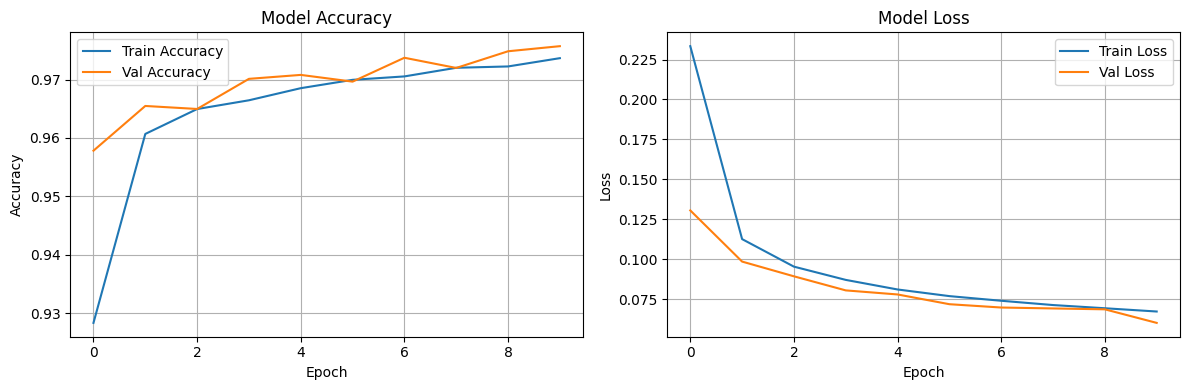

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()